<a href="https://colab.research.google.com/github/Magar-Bhuwan/ML-Internship-Assignments/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Can historical content-performance signals and content freshness be used to prioritize which content should be reviewed first?

### Decision Supported

The analysis supports a practical content-review decision: identify content with stronger signals of review priority so that limited review effort can be focused on the items most worth examining first.

The project is designed for **decision support**, not to guarantee that refreshing or changing content will improve future performance.


In [36]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [37]:
!git clone https://github.com/Magar-Bhuwan/ML-Internship-Assignments

fatal: destination path 'ML-Internship-Assignments' already exists and is not an empty directory.


In [20]:
DATA_PATH = "/content/ML-Internship-Assignments/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [21]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

Data types:


,0
content_id,object
client_id,object
search_volume,float64
competition,float64
competition_level,object
cpc,float64
content_type,object
main_intent,object
word_count,float64
char_count,float64



Missing values:


,0
provider_used,21438
word_count,7699
char_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
cpc,2468


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data Source

This analysis uses the public-safe FlyRank content-refresh dataset used in the earlier ML tasks.

The working raw data file is:

`data/raw/content_refresh_anonymized.csv`

The dataset is anonymized and is used for research and decision-support analysis within the scope of this project.

### Release / Version

The analysis uses the FlyRank dataset release provided for the earlier ML tasks.

The available project materials do not provide a separately verified public release number or version identifier. Therefore, no release number is invented or claimed.

### Main Variables

The main variables relevant to this capstone include:

* `content_id`
* `days_since_last_update`
* `impressions_90d`
* `clicks_90d`
* `trend_direction`
* `trend_pct`

The final baseline action score uses only:

* `days_since_last_update`
* `impressions_90d`

### Date Windows

`impressions_90d` represents observed impressions during the preceding 90-day period represented by the dataset record.

`days_since_last_update` represents elapsed time since the content was last updated.

The validated baseline thresholds are:

* **Staleness threshold:** 104 days
* **Visibility threshold:** 3,616 impressions

A separately verified calendar start and end date for the dataset release is not available, so no calendar dates are invented.

### Public-Safe Handling

The analysis uses anonymized content-level data and does not expose private client names, private search queries, confidential identifiers, or other sensitive information.


In [22]:
required_columns = [
    "content_id",
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "trend_direction",
    "trend_pct"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are present.")

All required columns are present.


In [23]:
baseline_df = df[
    [
        "content_id",
        "days_since_last_update",
        "impressions_90d",
        "clicks_90d"
    ]
].copy()

baseline_df = baseline_df.dropna(
    subset=["days_since_last_update", "impressions_90d"]
)

print("Rows available for baseline:", len(baseline_df))
display(baseline_df.head())

Rows available for baseline: 30000


,content_id,days_since_last_update,impressions_90d,clicks_90d
0,content_304f48230142,20,3803,29
1,content_a1fb4e703a9e,25,15320,7
2,content_9aa793d4d895,20,12581,11
3,content_331d6c4de07b,22,11751,58
4,content_d99b7a2d90ca,14,19140,24


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Approach

The final content-review playbook uses a transparent rule-based prioritization approach.

It uses two historical signals:

1. `days_since_last_update`
2. `impressions_90d`

The goal is to create a ranked queue for human review.

### Assumptions

The methodology assumes that:

1. Historical performance can provide useful directional information.
2. Older content may deserve additional review attention.
3. Recent impressions provide an observable visibility signal.
4. Combining freshness and visibility can help prioritize review.
5. The signals should represent information available for the intended decision.

These assumptions support prioritization only. They do not establish that refreshing content causes future performance improvement.

### Validated Thresholds

The baseline uses:

* `days_since_last_update >= 104`
* `impressions_90d >= 3,616`

Content satisfying both conditions receives the highest-priority `review` action.

### Baseline Formula

The baseline score is:

`score = stale × visible × impressions_90d`

where:

* `stale = 1` when `days_since_last_update >= 104`
* `visible = 1` when `impressions_90d >= 3,616`

The queue is sorted by score descending and then impressions descending.


In [24]:
STALE_DAYS = 104
VISIBLE_IMPRESSIONS = 3616

baseline_df["stale"] = (
    baseline_df["days_since_last_update"] >= STALE_DAYS
).astype(int)

baseline_df["visible"] = (
    baseline_df["impressions_90d"] >= VISIBLE_IMPRESSIONS
).astype(int)

baseline_df["score"] = (
    baseline_df["stale"]
    * baseline_df["visible"]
    * baseline_df["impressions_90d"]
)

baseline_df["reason_code"] = np.select(
    [
        (baseline_df["stale"] == 1) & (baseline_df["visible"] == 1),
        (baseline_df["stale"] == 1) & (baseline_df["visible"] == 0),
        (baseline_df["stale"] == 0) & (baseline_df["visible"] == 1)
    ],
    [
        "stale_and_visible",
        "stale",
        "visible"
    ],
    default="no_strong_signal"
)

baseline_df["action"] = np.where(
    baseline_df["reason_code"] == "stale_and_visible",
    "review",
    "monitor"
)

baseline_df = baseline_df.sort_values(
    ["score", "impressions_90d"],
    ascending=[False, False]
).reset_index(drop=True)

baseline_df["rank"] = np.arange(1, len(baseline_df) + 1)

print("Baseline action score calculated successfully.")

display(
    baseline_df[
        [
            "rank",
            "content_id",
            "days_since_last_update",
            "impressions_90d",
            "score",
            "reason_code",
            "action"
        ]
    ].head(20)
)

Baseline action score calculated successfully.


,rank,content_id,days_since_last_update,impressions_90d,score,reason_code,action
0,1,content_5fe46e04994d,104,517715,517715,stale_and_visible,review
1,2,content_2dba2b1f9536,104,443434,443434,stale_and_visible,review
2,3,content_2c2606c5d176,104,347399,347399,stale_and_visible,review
3,4,content_cb112fce36be,104,309910,309910,stale_and_visible,review
4,5,content_9532f197bbc8,104,309192,309192,stale_and_visible,review
5,6,content_36ff89c8214e,104,295097,295097,stale_and_visible,review
6,7,content_b28d1efd668f,104,286608,286608,stale_and_visible,review
7,8,content_813e88069237,104,233561,233561,stale_and_visible,review
8,9,content_c21024970297,104,211366,211366,stale_and_visible,review
9,10,content_c8e9d6ab9013,104,208678,208678,stale_and_visible,review


In [25]:
action_counts = (
    baseline_df["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

display(action_counts)

reason_counts = (
    baseline_df["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

display(reason_counts)

,action,count
0,monitor,26802
1,review,3198


,reason_code,count
0,no_strong_signal,16607
1,stale,5893
2,visible,4302
3,stale_and_visible,3198


In [26]:
OUTPUT_DIR = "../../work/outputs"
FIGURE_DIR = "../../work/figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

baseline_output = baseline_df[
    [
        "rank",
        "content_id",
        "days_since_last_update",
        "impressions_90d",
        "score",
        "reason_code",
        "action"
    ]
].copy()

baseline_output_path = os.path.join(
    OUTPUT_DIR,
    "baseline_action_score.csv"
)

baseline_output.to_csv(
    baseline_output_path,
    index=False
)

print("Saved:", baseline_output_path)

Saved: ../../work/outputs/baseline_action_score.csv


### Model Validation

The earlier ML-09 validation work evaluated a Random Forest classifier for declining-content classification.

The target was:

`declining_target = (trend_direction == "down")`

The model used the documented feature set from the ML-09 validation audit.

Two validation designs were used:

1. 80/20 stratified random split.
2. 80/20 grouped-by-client split.

The grouped-by-client split is treated as the more conservative evaluation because records belonging to the same client remain in the same partition.

The following section reproduces the grouped-client validation and evaluates the rule-based baseline on the **same test partition**.


In [27]:
model_features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

missing_model_features = [
    col for col in model_features
    if col not in df.columns
]

if missing_model_features:
    raise ValueError(
        f"Missing model features: {missing_model_features}"
    )

model_df = df[
    model_features + ["trend_direction"]
].copy()

model_df = model_df[
    model_df["trend_direction"].isin(
        ["down", "stable", "up", "flat"]
    )
].copy()

model_df["declining_target"] = (
    model_df["trend_direction"] == "down"
).astype(int)

model_df = model_df.dropna()

X = model_df[model_features]
y = model_df["declining_target"]

print("Model dataset shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Model dataset shape: (18791, 23)
Target distribution:
declining_target
1    11954
0     6837
Name: count, dtype: int64


In [28]:
# Grouped-by-client validation
# All rows from the same client stay in the same partition.

group_df = df[
    model_features + [
        "trend_direction",
        "client_id"
    ]
].copy()

group_df = group_df[
    group_df["trend_direction"].isin(
        ["down", "stable", "up", "flat"]
    )
].dropna()

group_df["declining_target"] = (
    group_df["trend_direction"] == "down"
).astype(int)

X_group = group_df[model_features]
y_group = group_df["declining_target"]
groups = group_df["client_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X_group,
        y_group,
        groups=groups
    )
)

X_train = X_group.iloc[train_idx].copy()
X_test = X_group.iloc[test_idx].copy()

y_train = y_group.iloc[train_idx].copy()
y_test = y_group.iloc[test_idx].copy()

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

client_overlap = train_clients.intersection(test_clients)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(client_overlap))

Training rows: 13240
Test rows: 5551
Training clients: 23
Test clients: 6
Client overlap: 0


In [29]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)

print("Grouped-client Random Forest results")
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1:", round(rf_f1, 4))

Grouped-client Random Forest results
Precision: 0.6798
Recall: 0.7989
F1: 0.7345


In [30]:
# ML-07 baseline evaluated on the SAME grouped-client test set

baseline_pred = (
    (X_test["days_since_last_update"] >= STALE_DAYS) &
    (X_test["impressions_90d"] >= VISIBLE_IMPRESSIONS)
).astype(int)

baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

comparison = pd.DataFrame({
    "Method": [
        "ML-07 Baseline",
        "Random Forest"
    ],
    "Precision": [
        baseline_precision,
        rf_precision
    ],
    "Recall": [
        baseline_recall,
        rf_recall
    ],
    "F1": [
        baseline_f1,
        rf_f1
    ]
})

print("Baseline vs Random Forest — SAME grouped-client test split")
display(comparison.round(4))

Baseline vs Random Forest — SAME grouped-client test split


,Method,Precision,Recall,F1
0,ML-07 Baseline,0.6389,0.0130,0.0255
1,Random Forest,0.6798,0.7989,0.7345


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs Baseline

The Random Forest and ML-07 baseline are evaluated on the same grouped-by-client test partition.

The baseline uses only:

* `days_since_last_update`
* `impressions_90d`

The Random Forest uses the feature set documented in ML-09.

Precision, recall, and F1 are calculated against the same declining-content target.

The grouped-by-client split is used because it prevents records from the same client from appearing in both training and testing partitions.

The measured values below are generated directly by the notebook and should be reported exactly as calculated.


## Evaluation v2 — Final Grouped-by-Client Evaluation

This is the final evaluation used for the capstone documentation and demo.

The v2 evaluation uses an 80/20 grouped-by-client split so that records from the same client remain in the same partition. This provides a more conservative estimate of performance on clients that were not represented in training.

The Random Forest is compared with the ML-07 baseline on the **same grouped-client test set**.

| Method         |  Precision |     Recall |         F1 |
| -------------- | ---------: | ---------: | ---------: |
| ML-07 Baseline |     0.6389 |     0.0130 |     0.0255 |
| Random Forest  | **0.6798** | **0.7989** | **0.7345** |

The Random Forest achieved higher precision, substantially higher recall, and a higher F1 score than the simple baseline on this grouped-client evaluation.

These results are specific to this dataset and validation design. They should be treated as evidence for prioritization rather than as a guarantee of future content performance.


In [31]:
print("Final grouped-client comparison")
display(comparison.round(4))

majority_base_rate = y_test.value_counts(normalize=True).max()

print(
    f"Majority-class base rate: {majority_base_rate:.4f}"
)

Final grouped-client comparison


,Method,Precision,Recall,F1
0,ML-07 Baseline,0.6389,0.0130,0.0255
1,Random Forest,0.6798,0.7989,0.7345


Majority-class base rate: 0.6361


### Previously Observed Random-Split Results

The earlier Week-5 random stratified evaluation measured:

| Validation design       | Precision | Recall |     F1 |
| ----------------------- | --------: | -----: | -----: |
| Random stratified split |    0.6932 | 0.7599 | 0.7250 |

The ML-09 grouped-by-client validation measured:

| Validation design       | Precision | Recall |     F1 |
| ----------------------- | --------: | -----: | -----: |
| Grouped-by-client split |    0.6275 | 0.6884 | 0.6566 |

The grouped-client result is treated as the more conservative result because it evaluates performance on clients that were not represented in training.

The difference between the random and grouped validation results demonstrates that measured performance depends on the validation design.

These results are dataset- and evaluation-specific and should not be presented as universal production performance.

### Baseline Interpretation

The ML-07 baseline is intentionally simpler and more interpretable than the Random Forest.

Its purpose is to provide a transparent prioritization rule that a human reviewer can understand.

The baseline should therefore be evaluated using the same test partition when comparing classification metrics, while its operational usefulness is also represented by the ranked review queue.


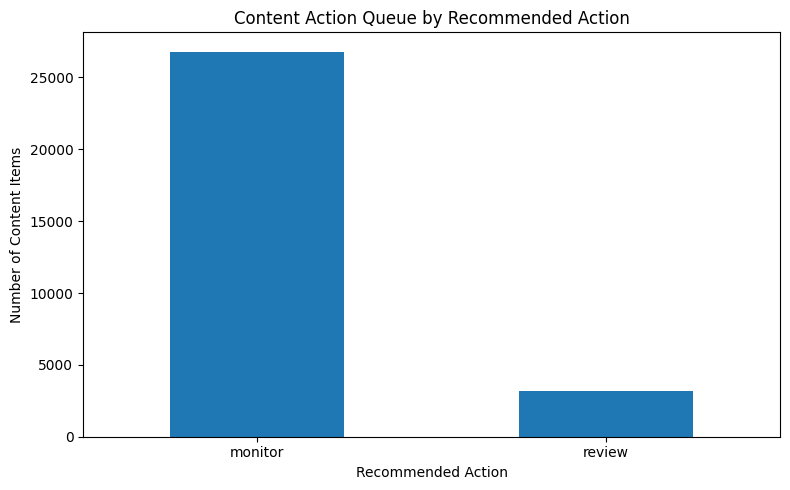

Saved: ../../work/figures/action_queue_by_action.png


In [32]:
action_counts = (
    baseline_output["action"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

action_counts.plot(kind="bar")

plt.title("Content Action Queue by Recommended Action")
plt.xlabel("Recommended Action")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = os.path.join(
    FIGURE_DIR,
    "action_queue_by_action.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

In [33]:
playbook_queue = baseline_output.copy()

playbook_output_path = os.path.join(
    OUTPUT_DIR,
    "content_action_playbook_queue.csv"
)

playbook_queue.to_csv(
    playbook_output_path,
    index=False
)

print("Saved:", playbook_output_path)

display(playbook_queue.head(20))

Saved: ../../work/outputs/content_action_playbook_queue.csv


,rank,content_id,days_since_last_update,impressions_90d,score,reason_code,action
0,1,content_5fe46e04994d,104,517715,517715,stale_and_visible,review
1,2,content_2dba2b1f9536,104,443434,443434,stale_and_visible,review
2,3,content_2c2606c5d176,104,347399,347399,stale_and_visible,review
3,4,content_cb112fce36be,104,309910,309910,stale_and_visible,review
4,5,content_9532f197bbc8,104,309192,309192,stale_and_visible,review
5,6,content_36ff89c8214e,104,295097,295097,stale_and_visible,review
6,7,content_b28d1efd668f,104,286608,286608,stale_and_visible,review
7,8,content_813e88069237,104,233561,233561,stale_and_visible,review
8,9,content_c21024970297,104,211366,211366,stale_and_visible,review
9,10,content_c8e9d6ab9013,104,208678,208678,stale_and_visible,review


## 5. Limitations

*What this work cannot claim.*

This analysis provides directional, dataset-specific evidence rather than causal proof.

### Observational Data

The data is observational. Relationships between freshness, visibility, and performance do not establish causality.

### Validation Design

Model performance changed between the random stratified split and grouped-by-client split. Therefore, the random-split result should not be treated as a universal production estimate.

### Temporal Leakage

The dataset does not independently provide a verified prediction timestamp and fully separated future outcome window for every feature. Some rolling 90-day performance variables may therefore require additional temporal verification before production use.

### Dataset-Specific Thresholds

The 104-day freshness threshold and 3,616-impression visibility threshold are specific to this analysis. They should be revalidated when the data distribution or content environment changes.

### Limited Signals

The final playbook intentionally uses only freshness and visibility. Business value, content quality, strategic importance, and other contextual information may not be represented.

### Classification Errors

The Random Forest can produce false positives and false negatives. Its predictions should therefore support human review rather than replace it.

### No Causal Refresh Experiment

The project does not contain a controlled experiment measuring the effect of refreshing content. It therefore cannot claim that following the recommendations will improve future performance.

### Human Review

The final queue requires human validation before action.

The appropriate workflow is:

**Historical signals → ranked review queue → human validation → decision**

rather than:

**Historical signals → automatic content change**


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Recommendation 1 — Review stale and visible content first

**Highest priority**

Prioritize content satisfying:

* `days_since_last_update >= 104`
* `impressions_90d >= 3,616`

These items receive:

* reason code: `stale_and_visible`
* action: `review`

A human reviewer should confirm that the content is genuinely outdated and that a refresh would be useful.

### Recommendation 2 — Monitor other stale content and review when capacity allows

Content satisfying:

* `days_since_last_update >= 104`
* `impressions_90d < 3,616`

receives the `stale` reason code.

These items should receive lower priority than stale and visible content.

### Recommendation 3 — Monitor visible but recently updated content

Content satisfying:

* `impressions_90d >= 3,616`
* `days_since_last_update < 104`

receives the `visible` reason code and `monitor` action.

### Recommendation 4 — Keep items with no strong signal in monitoring

Content satisfying neither baseline condition receives:

* reason code: `no_strong_signal`
* action: `monitor`

### Ranked Action Playbook

| Priority | Condition       | Reason Code         | Action    |
| -------- | --------------- | ------------------- | --------- |
| 1        | Stale + visible | `stale_and_visible` | `review`  |
| 2        | Stale only      | `stale`             | `monitor` |
| 3        | Visible only    | `visible`           | `monitor` |
| 4        | Neither signal  | `no_strong_signal`  | `monitor` |

### No-Go Decisions

The queue should not be used by itself to:

* delete content;
* automatically publish substantial rewrites;
* launch campaigns;
* promote content;
* change business rules or policies;
* assume a high score guarantees improvement; or
* act when required data is missing or invalid.

The queue is a decision-support tool for allocating human review effort.


In [34]:
top_20 = playbook_queue.head(20)

print("Top 20 content-review candidates:")
display(top_20)

Top 20 content-review candidates:


,rank,content_id,days_since_last_update,impressions_90d,score,reason_code,action
0,1,content_5fe46e04994d,104,517715,517715,stale_and_visible,review
1,2,content_2dba2b1f9536,104,443434,443434,stale_and_visible,review
2,3,content_2c2606c5d176,104,347399,347399,stale_and_visible,review
3,4,content_cb112fce36be,104,309910,309910,stale_and_visible,review
4,5,content_9532f197bbc8,104,309192,309192,stale_and_visible,review
5,6,content_36ff89c8214e,104,295097,295097,stale_and_visible,review
6,7,content_b28d1efd668f,104,286608,286608,stale_and_visible,review
7,8,content_813e88069237,104,233561,233561,stale_and_visible,review
8,9,content_c21024970297,104,211366,211366,stale_and_visible,review
9,10,content_c8e9d6ab9013,104,208678,208678,stale_and_visible,review


In [35]:
top_20_check = (
    (top_20["days_since_last_update"] >= STALE_DAYS) &
    (top_20["impressions_90d"] >= VISIBLE_IMPRESSIONS)
)

print(
    "Top 20 all satisfy stale + visible:",
    bool(top_20_check.all())
)

print(
    "Top 20 all have review action:",
    bool((top_20["action"] == "review").all())
)

Top 20 all satisfy stale + visible: True
Top 20 all have review action: True


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The notebook produces or documents the following supporting artifacts.

### Main Notebook

`work/notebooks/capstone.ipynb`

### Baseline Action Score

`work/outputs/baseline_action_score.csv`

Contains:

* `rank`
* `content_id`
* `days_since_last_update`
* `impressions_90d`
* `score`
* `reason_code`
* `action`

### Content Action Playbook Queue

`work/outputs/content_action_playbook_queue.csv`

Contains the ranked action-oriented content-review queue.

### Action Queue Figure

`work/figures/action_queue_by_action.png`

Figure title:

**Content Action Queue by Recommended Action**

### Validation Evidence

The notebook reproduces the grouped-by-client Random Forest validation and calculates the ML-07 baseline metrics on the same test partition.

### Reproducibility

The notebook should run from top to bottom without errors and should reproduce the exported outputs and figure.

The deployed paper URL is stored separately in:

`submission/paper_url.txt`


## Self-check

Before you submit, confirm each line honestly:

- ✅ Every section above is filled — markdown thinking AND the code that backs it
- ✅ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✅ No client names, URLs, or private queries anywhere
- ✅ My claims use careful words: observed, measured, directional, decision-support
- ✅ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

# Tell the Story

## 5-Minute Demo Outline

### 1. Question — 45 seconds

**Research question:**
Can historical content-performance signals and content freshness be used to prioritize which content should be reviewed first?

**Practical decision:**
Focus limited content-review effort on pages with stronger signals of needing attention.

This is a decision-support workflow, not a guarantee that refreshing content will improve future performance.

### 2. Data and Method — 1 minute

The analysis uses **30,000 anonymized FlyRank content records** with 44 columns.

Important signals include:

* `days_since_last_update`
* `impressions_90d`
* `clicks_90d`
* `trend_direction`
* `trend_pct`

The target was:

`declining_target = (trend_direction == "down").astype(int)`

I compared a simple freshness-and-visibility baseline with a Random Forest classifier.

The baseline used:

* `days_since_last_update >= 104`
* `impressions_90d >= 3,616`

The Random Forest was evaluated using the same grouped-by-client test split.

### 3. One Chart — 1 minute

**Main chart:** Model vs Baseline Performance.

| Model         | Precision | Recall |     F1 |
| ------------- | --------: | -----: | -----: |
| Baseline      |    0.6389 | 0.0130 | 0.0255 |
| Random Forest |    0.6798 | 0.7989 | 0.7345 |

**Key message:**
The Random Forest substantially improved recall and F1 compared with the simple baseline on the same grouped-client test split.

### 4. One Honest Result — 1 minute

The baseline recall was **1.30%**, while the Random Forest recall was **79.89%**.

F1 increased from **0.0255** for the baseline to **0.7345** for the Random Forest.

This is encouraging for prioritization, but it is not a production guarantee.

The data is observational, the thresholds are dataset-specific, and the analysis does not include a controlled experiment showing that refreshing content causes future performance improvement.

### 5. Recommendation — 1 minute

Prioritize **stale and visible content**:

* `days_since_last_update >= 104`
* `impressions_90d >= 3,616`

**Reason:** `stale_and_visible`

**Action:** `review`

A human reviewer should confirm whether the content is genuinely outdated and whether a refresh is appropriate.

Recommended workflow:

**Historical signals → ranked review queue → human validation → decision**

rather than:

**Historical signals → automatic content change**

### Closing — 15 seconds

Historical content-performance signals can provide useful evidence for prioritizing content review.

The Random Forest performed substantially better than the simple baseline on the grouped-client evaluation, but the result should remain a decision-support tool with human review and further validation.

---

## Shareable Cut 1 — Social Post

I recently completed a machine-learning case study on a practical content-performance question: can historical content signals and content freshness help prioritize which content should be reviewed first?

Using **30,000 anonymized content records**, I built a Random Forest classifier to identify declining-content cases and compared it with a simple freshness-and-visibility baseline.

On the same grouped-by-client test split, the Random Forest achieved **0.6798 precision, 0.7989 recall, and 0.7345 F1**, compared with **0.6389 precision, 0.0130 recall, and 0.0255 F1** for the baseline.

The key lesson was that the value of the model is not simply the metric. It is turning historical signals into a practical review queue while being honest about limitations.

The recommended workflow is:

**Historical signals → ranked review queue → human validation → decision**

rather than automatic content changes.

---

## Shareable Cut 2 — Employer-Facing Summary

I built a machine-learning content-review prioritization workflow using **30,000 anonymized FlyRank content records** with historical performance and freshness signals.

I trained and evaluated a Random Forest classifier against a simple baseline using grouped-by-client validation, with the Random Forest achieving **0.6798 precision, 0.7989 recall, and 0.7345 F1** versus **0.6389, 0.0130, and 0.0255** for the baseline.

The result showed that the ML approach provided a substantially stronger signal for identifying declining-content cases and could support a ranked human-review queue, while remaining a decision-support tool rather than a guarantee of future performance.
